## Individual Household Electric Power Consumption Dataset Notebook

### Exploratory Data Analysis (EDA)
#### Energy Demand Forecasting Dataset

This notebook performs:
- Data loading and inspection
- Cleaning, missing value handling, type conversion, feature engineering, resampling
- Preparation for time-series forecasting
- Sampling for descriptive stats (100 rows)
- Exploratory descriptive statistics
- Visualizations (time series, histogram, boxplot, pivot table)
- Train/validation/test split
- Saving processed data 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display all columns
pd.set_option("display.max_columns", None)

### Load Dataset

The dataset is a semicolon-delimited `.txt` file with `Date` and `Time` columns.  
Missing values are represented as `?` and will be converted to `NaN`.  
We combine `Date` and `Time` into a single `Datetime` column.

In [2]:
file_path = "../data/raw/household_power_consumption.txt"

# Step 1: Load dataset without parsing dates
df = pd.read_csv(
    file_path,
    sep=';',
    na_values=['?', ''],
    skipinitialspace=True,
    low_memory=False
)

# Clean whitespace
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df = df.replace(r'^\s*$', np.nan, regex=True)

# Combine datetime safely
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    dayfirst=True,
    errors='coerce'
)

# Drop original columns
df = df.drop(columns=['Date', 'Time'])

df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


### Dataset Overview

We check the shape, column types, and basic statistics.

In [3]:
print("Shape:", df.shape)
df.info()
df.describe()

Shape: (2075259, 8)
<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   Global_active_power    float64       
 1   Global_reactive_power  float64       
 2   Voltage                float64       
 3   Global_intensity       float64       
 4   Sub_metering_1         float64       
 5   Sub_metering_2         float64       
 6   Sub_metering_3         float64       
 7   Datetime               datetime64[us]
dtypes: datetime64[us](1), float64(7)
memory usage: 126.7 MB


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
count,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2.049280e+06,2075259
mean,1.091615e+00,1.237145e-01,2.408399e+02,4.627759e+00,1.121923e+00,1.298520e+00,6.458447e+00,2008-12-06 07:13:00
min,7.600000e-02,0.000000e+00,2.232000e+02,2.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,2006-12-16 17:24:00
25%,3.080000e-01,4.800000e-02,2.389900e+02,1.400000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2007-12-12 00:18:30
50%,6.020000e-01,1.000000e-01,2.410100e+02,2.600000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2008-12-06 07:13:00
75%,1.528000e+00,1.940000e-01,2.428900e+02,6.400000e+00,0.000000e+00,1.000000e+00,1.700000e+01,2009-12-01 14:07:30
max,1.112200e+01,1.390000e+00,2.541500e+02,4.840000e+01,8.800000e+01,8.000000e+01,3.100000e+01,2010-11-26 21:02:00
std,1.057294e+00,1.127220e-01,3.239987e+00,4.444396e+00,6.153031e+00,5.822026e+00,8.437154e+00,NaN


### Missing Values

Convert `?` to NaN (done during loading).  
We check which columns contain missing values.

In [4]:
missing = df.isna().sum()
missing[missing > 0]

Global_active_power      25979
Global_reactive_power    25979
Voltage                  25979
Global_intensity         25979
Sub_metering_1           25979
Sub_metering_2           25979
Sub_metering_3           25979
dtype: int64

### Data Cleaning

1. Convert all measurement columns to float.  
2. Drop rows with missing values.  
3. Sort dataset chronologically by `Datetime`.

In [5]:
for col in df.columns:
    if col != "Datetime":
        df[col] = pd.to_numeric(df[col], errors='coerce')

# drop missing
measurement_cols = [col for col in df.columns if col != "Datetime"]
df = df.dropna()

# sort
df = df.sort_values("Datetime")
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00


### Feature Engineering

Extract temporal features from datetime:
- Hour
- Day
- Month
These features help capture daily/seasonal patterns.

In [6]:
df["hour"] = df["Datetime"].dt.hour
df["day"] = df["Datetime"].dt.day
df["month"] = df["Datetime"].dt.month
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,hour,day,month
0,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,17,16,12
1,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,17,16,12
2,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,17,16,12
3,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,17,16,12
4,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,17,16,12


### Resampling Data

Original data is recorded at 1-minute intervals.  
To reduce noise and computation, we aggregate to **hourly averages**.  

> **Note:** After resampling, the original `Datetime` column is retained as numeric mean, which is redundant. We drop it to avoid confusion.

In [7]:
df = df.set_index("Datetime")
hourly_df = df.resample("h").mean()
hourly_df = hourly_df.reset_index()
hourly_df = hourly_df.dropna()
hourly_df.head()

,Datetime,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,day,month
0,2006-12-16 17:00:00,4.222889,0.229000,234.643889,18.100000,0.0,0.527778,16.861111,17.0,16.0,12.0
1,2006-12-16 18:00:00,3.632200,0.080033,234.580167,15.600000,0.0,6.716667,16.866667,18.0,16.0,12.0
2,2006-12-16 19:00:00,3.400233,0.085233,233.232500,14.503333,0.0,1.433333,16.683333,19.0,16.0,12.0
3,2006-12-16 20:00:00,3.268567,0.075100,234.071500,13.916667,0.0,0.000000,16.783333,20.0,16.0,12.0
4,2006-12-16 21:00:00,3.056467,0.076667,237.158667,13.046667,0.0,0.416667,17.216667,21.0,16.0,12.0


### Descriptive Statistics (Sampled)

The dataset has over 2 million rows. To compute descriptive statistics efficiently, we take a **random sample of 100 rows**.

In [8]:
# Sample 100 rows
sample_df = hourly_df.sample(n=100, random_state=46)

# Descriptive statistics for all numerical columns
sample_stats = sample_df.describe().round(2)
print("Descriptive Statistics (Sample of 100 rows):")
print(sample_stats)

# Median and mode for the target variable: Global Active Power
median = round(sample_df["Global_active_power"].median(), 2)
mode = round(sample_df["Global_active_power"].mode()[0], 2)

print(f"\nTarget Variable: Global_active_power")
print(f"Median: {median} kW")
print(f"Mode: {mode} kW")

Descriptive Statistics (Sample of 100 rows):
                  Datetime  Global_active_power  Global_reactive_power  \
count                  100               100.00                 100.00   
mean   2008-12-12 00:28:48                 1.17                   0.14   
min    2007-01-11 00:00:00                 0.15                   0.04   
25%    2008-02-14 11:00:00                 0.40                   0.08   
50%    2008-11-09 23:30:00                 0.90                   0.12   
75%    2009-11-01 18:30:00                 1.61                   0.18   
max    2010-11-07 23:00:00                 4.56                   0.47   
std                    NaN                 0.96                   0.08   

       Voltage  Global_intensity  Sub_metering_1  Sub_metering_2  \
count   100.00            100.00          100.00          100.00   
mean    240.64              4.98            1.85            1.52   
min     232.50              0.71            0.00            0.00   
25%     238.77  

### Time Series Visualization

Visualizing hourly global active power to detect trends and patterns.

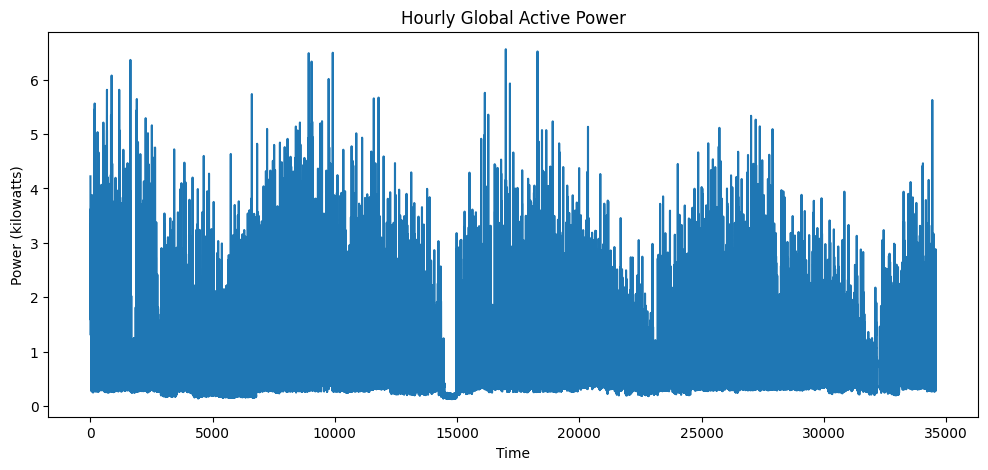

In [9]:
plt.figure(figsize=(12,5))
hourly_df["Global_active_power"].plot()
plt.title("Hourly Global Active Power")
plt.xlabel("Time")
plt.ylabel("Power (kilowatts)")
plt.show()

### Distribution of Global Active Power

Histogram shows the frequency distribution of hourly consumption.

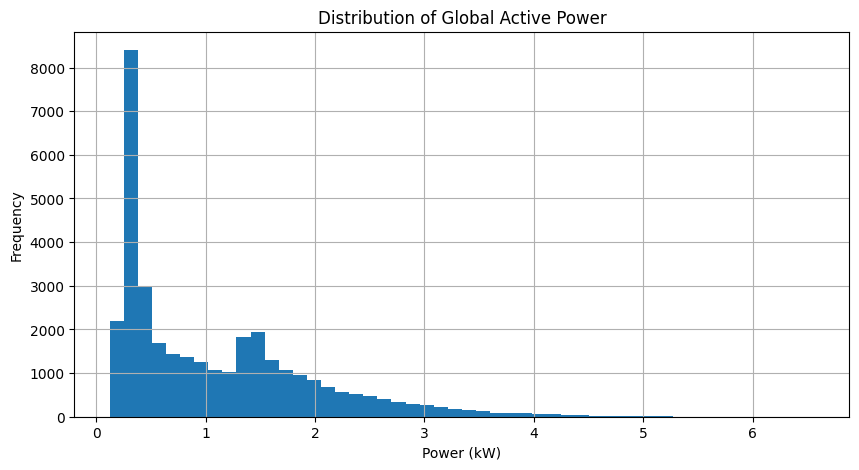

In [10]:
plt.figure(figsize=(10,5))
hourly_df["Global_active_power"].hist(bins=50)
plt.title("Distribution of Global Active Power")
plt.xlabel("Power (kW)")
plt.ylabel("Frequency")
plt.show()

### Consumption Patterns by Hour

Boxplot shows variation of energy consumption throughout the day.

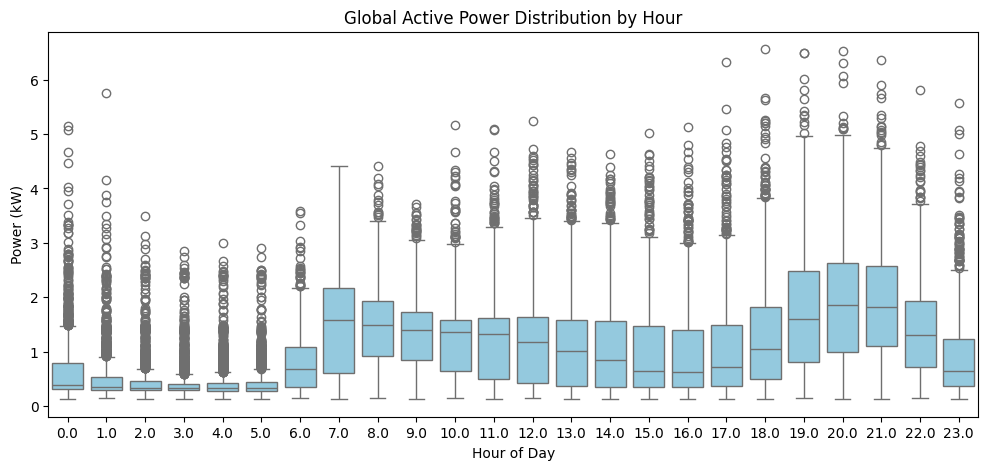

In [11]:
plt.figure(figsize=(12,5))
sns.boxplot(
    x="hour",
    y="Global_active_power",
    data=hourly_df.reset_index(),
    color="skyblue"
)
plt.title("Global Active Power Distribution by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Power (kW)")
plt.show()

### Average Hourly Consumption by Month

Pivot table shows hourly trends across months to identify seasonal effects.

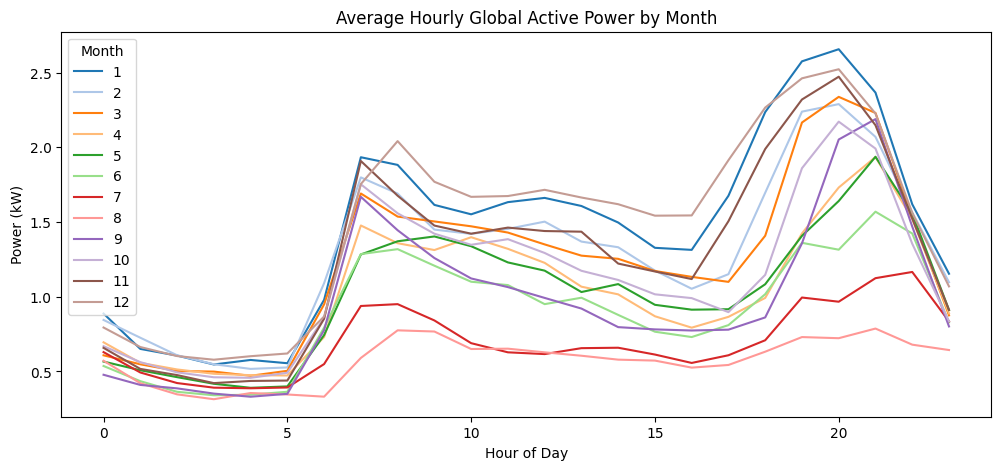

In [12]:
hourly_df['month'] = hourly_df['Datetime'].dt.month
pivot = hourly_df.pivot_table(
    values='Global_active_power', 
    index='hour', 
    columns='month', 
    aggfunc='mean'
)

colors = plt.colormaps["tab20"].colors[:12]

pivot.plot(figsize=(12,5), color=colors)
plt.title("Average Hourly Global Active Power by Month")
plt.xlabel("Hour of Day")
plt.ylabel("Power (kW)")
plt.legend(title="Month")
plt.show()

### Chronological Train/Validation/Test Split

70% Train, 15% Validation, 15% Test to avoid leakage.

In [15]:
n = len(hourly_df)
train = hourly_df[:int(n*0.7)]
val = hourly_df[int(n*0.7):int(n*0.85)]
test = hourly_df[int(n*0.85):]

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")

Train: 23917, Val: 5125, Test: 5126


### Save Processed Data

Save the splits for later use in the modeling pipeline.

In [16]:
train.to_csv("../data/train.csv", index=False)
val.to_csv("../data/val.csv", index=False)
test.to_csv("../data/test.csv", index=False)
hourly_df.to_csv("../data/processed_full.csv", index=False)